<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0' role="tab" aria-controls="home"><center>APRENDIZADO DE MÁQUINA (CIC1205/GCC1932) - Trabalho 2</center></h1>

- Nome completo: <João Pedro Jendiroba Paixão Corrêa>
- [Link para vídeo](<https://www.youtube.com/watch?v=hN-K-voHV9k>)

# (2) Classificação Ordinal Multiclasse (2 pts)

## 2.1 EDA 

In [2]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split

f = open("../data/A652.pickle" , "rb")
X_train_old, y_train_old, X_val_old, y_val_old, X_test_old, y_test_old = pickle.load(f)

X_total = np.concatenate([X_train_old, X_val_old, X_test_old], axis=0)
y_total = np.concatenate([y_train_old, y_val_old, y_test_old], axis=0)

X_train, X_test, y_train, y_test = train_test_split(
    X_total, y_total, test_size=0.2, random_state=42
)
print("Shapes:", X_train.shape, X_test.shape)

Shapes: (17680, 24) (4420, 24)


In [3]:
X_train_df = pd.DataFrame(X_train)
y_train_df = pd.DataFrame(y_train, columns=["precipitacao"])

display(X_train_df.head())
display(y_train_df.head(5))
display(y_train_df.describe().round(2))

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,0.221675,0.665414,0.597222,0.539365,0.194582,0.853553,0.853553,0.0,0.211823,0.646617,...,0.750000,0.0,0.192118,0.631579,0.611111,0.515658,0.276719,0.982963,0.629410,0.0
1,0.655172,0.409774,0.583333,0.525402,0.176706,0.629410,0.017037,0.0,0.768473,0.413534,...,0.000000,0.0,0.852217,0.409774,0.291667,0.454617,0.257935,0.370590,0.017037,0.0
2,0.596059,0.503759,0.680556,0.369335,0.274875,0.500000,0.000000,0.0,0.679803,0.500000,...,0.017037,0.0,0.748768,0.496241,0.555556,0.433311,0.439288,0.250000,0.066987,0.0
3,0.655172,0.383459,0.527778,0.313066,0.399591,0.000000,0.500000,0.0,0.620690,0.360902,...,0.629410,0.0,0.482759,0.360902,0.694444,0.329622,0.354452,0.066987,0.750000,0.0
4,0.463054,0.315789,0.472222,0.301577,0.306178,0.146447,0.853553,0.0,0.463054,0.345865,...,0.933013,0.0,0.310345,0.372180,0.680556,0.623952,0.305891,0.370590,0.982963,0.0


,precipitacao
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


,precipitacao
count,17680.00
mean,0.16
std,1.19
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,60.40


## 2.2 Mudança na abordagem do alvo

Os dados em Y são para um problema de regressão, mas vamos trabalhar com uma abordagem de **Classificação Ordinal Multiclasse**. Ou seja, vamos transformar a variável alvo precipitação (número real - mm/h) em classes baseadas na quantidade da chuva: None, Weak, Moderate, Strong e Extreme, ajustadas conforme a quantidade de precipitação. E não só isso, vamos passar informação de ordem das classes conforme prevê a estratégia de Classificação Ordinal Multiclasse. 

In [4]:
classes_precipitacao = ["NONE", "WEAK", "MODERATE", "STRONG", "EXTREME"]
tipo_ordinal_precipitacao = pd.CategoricalDtype(
    categories=classes_precipitacao,
    ordered=True
)

def discretizar_precipitacao(y):
    y_array = np.asarray(y).ravel()

    condicoes = [
        y_array == 0,
        (y_array > 0) & (y_array <= 5),
        (y_array > 5) & (y_array <= 25),
        (y_array > 25) & (y_array <= 50),
        y_array > 50,
    ]

    y_classes = np.select(condicoes, classes_precipitacao, default=None)
    return pd.Series(y_classes, name="precipitacao_classe").astype(tipo_ordinal_precipitacao)

y_train_mm = y_train.copy()
y_test_mm = y_test.copy()

y_train = discretizar_precipitacao(y_train_mm)
y_test = discretizar_precipitacao(y_test_mm)

mapeamento_precipitacao = pd.DataFrame({
    "intervalo_mm_h": ["0", "(0, 5]", "(5, 25]", "(25, 50]", "(50, infinito)"],
    "classe": classes_precipitacao,
})

display(mapeamento_precipitacao)
display(y_train.value_counts(sort=False).rename("quantidade_treino").to_frame())
display(y_test.value_counts(sort=False).rename("quantidade_teste").to_frame())

,intervalo_mm_h,classe
0,0,NONE
1,"(0, 5]",WEAK
2,"(5, 25]",MODERATE
3,"(25, 50]",STRONG
4,"(50, infinito)",EXTREME


,quantidade_treino
precipitacao_classe,
NONE,16222
WEAK,1335
MODERATE,116
STRONG,6
EXTREME,1


,quantidade_teste
precipitacao_classe,
NONE,4082
WEAK,308
MODERATE,28
STRONG,1
EXTREME,1


## 2.3 Refazendo o split preservando a ordem temporal

As observações de precipitação são uma **série temporal**, então misturar passado e futuro no split levaria a vazamento de informação (data leakage temporal). Refazemos o split com `shuffle=False`: as primeiras 80% das amostras viram treino e os últimos 20% viram teste, mantendo a ordem original do pickle.

**Consequência:** não podemos estratificar (`stratify` exige `shuffle=True`). Isso significa que a distribuição de classes raras no teste depende inteiramente de onde elas caem na linha do tempo. Vamos imprimir as contagens para deixar essa distribuição explícita e considerá-la na interpretação das métricas.


In [6]:
import pickle
import numpy as np
from sklearn.model_selection import train_test_split

with open("../data/A652.pickle", "rb") as f:
    X_tr_old, y_tr_old, X_val_old, y_val_old, X_te_old, y_te_old = pickle.load(f)

X_total = np.concatenate([X_tr_old, X_val_old, X_te_old], axis=0)
y_total_mm = np.concatenate([y_tr_old, y_val_old, y_te_old], axis=0)
y_total_classes = discretizar_precipitacao(y_total_mm)

# shuffle=False preserva a ordem temporal (não pode usar stratify junto)
X_train, X_test, y_train, y_test = train_test_split(
    X_total,
    y_total_classes,
    test_size=0.2,
    shuffle=False,
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print("\nDistribuição no treino:")
display(y_train.value_counts(sort=False).rename("qtd_treino").to_frame())
print("Distribuição no teste:")
display(y_test.value_counts(sort=False).rename("qtd_teste").to_frame())


X_train: (17680, 24)  |  X_test: (4420, 24)

Distribuição no treino:


,qtd_treino
precipitacao_classe,
NONE,16231
WEAK,1321
MODERATE,123
STRONG,4
EXTREME,1


Distribuição no teste:


,qtd_teste
precipitacao_classe,
NONE,4073
WEAK,322
MODERATE,21
STRONG,3
EXTREME,1


## 2.4 Transformação ordinal → K−1 alvos binários

Conforme a Figura 2 do paper de Frank & Hall, um problema com K classes ordenadas vira K−1 problemas binários. O k-ésimo classificador aprende `rank(y) > V_k`. Para as nossas 5 classes:

| k | Tarefa binária    |
|---|-------------------|
| 0 | y > NONE          |
| 1 | y > WEAK          |
| 2 | y > MODERATE      |
| 3 | y > STRONG        |


In [7]:
def ordinal_to_binary_targets(y_ordinal, classes_ordenadas):
    """Retorna matriz (n, K-1) onde a coluna k vale 1 se rank(y) > k."""
    rank_map = {c: i for i, c in enumerate(classes_ordenadas)}
    ranks = np.array([rank_map[v] for v in y_ordinal])
    K = len(classes_ordenadas)
    Y_bin = np.zeros((len(y_ordinal), K - 1), dtype=int)
    for k in range(K - 1):
        Y_bin[:, k] = (ranks > k).astype(int)
    return Y_bin

Y_train_bin = ordinal_to_binary_targets(y_train, classes_precipitacao)
Y_test_bin = ordinal_to_binary_targets(y_test, classes_precipitacao)

print(f"Y_train_bin shape: {Y_train_bin.shape}  (n_treino, K-1)")
print("\nPositivos por classificador binário (treino):")
for k, classe in enumerate(classes_precipitacao[:-1]):
    n_pos = Y_train_bin[:, k].sum()
    n_neg = len(Y_train_bin) - n_pos
    print(f"  k={k}  y > {classe:<8}  positivos={n_pos:>5}  negativos={n_neg:>5}")


Y_train_bin shape: (17680, 4)  (n_treino, K-1)

Positivos por classificador binário (treino):
  k=0  y > NONE      positivos= 1449  negativos=16231
  k=1  y > WEAK      positivos=  128  negativos=17552
  k=2  y > MODERATE  positivos=    5  negativos=17675
  k=3  y > STRONG    positivos=    1  negativos=17679


## 2.5 Treino dos K−1 classificadores binários

Cada um dos 4 classificadores é um `GradientBoostingClassifier` independente, sobre o mesmo `X_train`. O `GradientBoostingClassifier` não aceita o parâmetro `class_weight`, então passamos pesos por amostra (`sample_weight`) calculados via `compute_sample_weight('balanced', y)` — equivalente direto ao `class_weight='balanced'` de outros estimadores.

As features do pickle já vêm normalizadas em [0, 1], então não há etapa de pré-processamento extra (apesar de árvores não exigirem escala).

Observação: para `k=3` (`y > STRONG`) só há ~6 amostras positivas no treino. Esperamos um modelo degenerado — vamos reportar isso explicitamente, não corrigir.


In [8]:
import warnings
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

binary_classifiers = []

for k, classe in enumerate(classes_precipitacao[:-1]):
    y_k = Y_train_bin[:, k]
    n_pos, n_neg = int(y_k.sum()), int(len(y_k) - y_k.sum())

    clf = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
    )
    # equivalente direto a class_weight='balanced'
    sw = compute_sample_weight(class_weight="balanced", y=y_k)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # warnings esperados quando n_pos é minúsculo
        clf.fit(X_train, y_k, sample_weight=sw)
    binary_classifiers.append(clf)

    print(f"k={k}  y > {classe:<8}  treinado  (pos={n_pos}, neg={n_neg})")


k=0  y > NONE      treinado  (pos=1449, neg=16231)
k=1  y > WEAK      treinado  (pos=128, neg=17552)
k=2  y > MODERATE  treinado  (pos=5, neg=17675)
k=3  y > STRONG    treinado  (pos=1, neg=17679)


## 2.6 Predição combinada (fórmulas do paper)

Com os K−1 modelos treinados, reconstruímos a distribuição sobre as K classes originais combinando as probabilidades `p_k = P(y > V_k | X)`:

- `P(V_1) = 1 − p_1`
- `P(V_i) = p_{i−1} × (1 − p_i)`  para `1 < i < K`
- `P(V_K) = p_{K−1}`

A classe predita é o `argmax`. Vale notar que essas probabilidades **não somam exatamente 1** em geral — é uma limitação conhecida da decomposição, mas não afeta a predição por `argmax`.


In [9]:
def predict_ordinal(X, models, classes_ordenadas):
    """Combina os K-1 classificadores binários nas K probabilidades originais.
    Retorna: (probas (n, K), classe_predita (n,)).
    """
    K = len(classes_ordenadas)
    # p[:, k] = P(y > V_k | X) do k-ésimo classificador
    p = np.column_stack([m.predict_proba(X)[:, 1] for m in models])

    probas = np.zeros((X.shape[0], K))
    probas[:, 0] = 1.0 - p[:, 0]                                # P(V_1)
    for i in range(1, K - 1):                                   # P(V_i), 1 < i < K
        probas[:, i] = p[:, i - 1] * (1.0 - p[:, i])
    probas[:, K - 1] = p[:, K - 2]                              # P(V_K)

    idx_pred = probas.argmax(axis=1)
    classes_arr = np.array(classes_ordenadas)
    return probas, classes_arr[idx_pred]

probas_test, y_pred_fh = predict_ordinal(X_test, binary_classifiers, classes_precipitacao)

print(f"probas_test shape: {probas_test.shape}")
print(f"Soma das probas (primeiras 5 amostras): {probas_test[:5].sum(axis=1).round(4)}")
print("  (não somam exatamente 1 — esperado pela decomposição)\n")

print("Distribuição das classes preditas:")
display(
    pd.Series(y_pred_fh, name="classe_predita")
    .astype(tipo_ordinal_precipitacao)
    .value_counts(sort=False)
    .rename("qtd_predita")
    .to_frame()
)


probas_test shape: (4420, 5)
Soma das probas (primeiras 5 amostras): [1.0035 1.0075 1.0072 1.0118 1.0125]
  (não somam exatamente 1 — esperado pela decomposição)

Distribuição das classes preditas:


,qtd_predita
classe_predita,
NONE,4032
WEAK,331
MODERATE,57
STRONG,0
EXTREME,0


## 2.7 Avaliação

Para um problema ordinal desbalanceado, acurácia sozinha é enganosa (basta sempre prever NONE). Reportamos:

- **Accuracy**: referência.
- **Macro-F1**: penaliza ignorar classes minoritárias.
- **MAE ordinal**: erro absoluto médio entre rank predito e rank verdadeiro.
- **Quadratic Weighted Kappa (QWK)**: métrica padrão para classificação ordinal.
- **Matriz de confusão** na ordem ordinal correta.

Comparamos contra um `DummyClassifier` (sempre NONE) e contra uma `LogisticRegression` multinomial **nominal** (sem Frank & Hall), para confirmar que o ganho vem do aproveitamento da informação ordinal — não só de transformar o problema em vários binários.


In [10]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
)
from sklearn.dummy import DummyClassifier
from sklearn.utils.class_weight import compute_sample_weight

rank_map = {c: i for i, c in enumerate(classes_precipitacao)}
y_test_rank = np.array([rank_map[v] for v in y_test])


def avaliar(y_true_cat, y_pred_cat, nome):
    y_true_r = np.array([rank_map[v] for v in y_true_cat])
    y_pred_r = np.array([rank_map[v] for v in y_pred_cat])
    return {
        "modelo": nome,
        "accuracy": accuracy_score(y_true_cat, y_pred_cat),
        "macro_f1": f1_score(
            y_true_cat, y_pred_cat, average="macro", labels=classes_precipitacao, zero_division=0
        ),
        "mae_ordinal": mean_absolute_error(y_true_r, y_pred_r),
        "qwk": cohen_kappa_score(y_true_r, y_pred_r, weights="quadratic"),
    }


# Baseline 1: sempre prevê a classe majoritária (NONE)
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = pd.Series(dummy.predict(X_test)).astype(tipo_ordinal_precipitacao)

# Baseline 2: GBC multiclasse nominal (ignora a ordem)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    nominal = GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42
    )
    sw_nominal = compute_sample_weight(class_weight="balanced", y=y_train)
    nominal.fit(X_train, y_train, sample_weight=sw_nominal)
y_pred_nominal = pd.Series(nominal.predict(X_test)).astype(tipo_ordinal_precipitacao)

y_pred_fh_cat = pd.Series(y_pred_fh).astype(tipo_ordinal_precipitacao)

resultados = pd.DataFrame([
    avaliar(y_test, y_pred_dummy, "Dummy (sempre NONE)"),
    avaliar(y_test, y_pred_nominal, "GBC nominal (sem ordem)"),
    avaliar(y_test, y_pred_fh_cat, "Frank & Hall (GBC ordinal)"),
])

display(resultados.round(4))


,modelo,accuracy,macro_f1,mae_ordinal,qwk
0,Dummy (sempre NONE),0.9215,0.1918,0.0853,0.0000
1,GBC nominal (sem ordem),0.9197,0.3187,0.0860,0.4829
2,Frank & Hall (GBC ordinal),0.9161,0.3153,0.0891,0.5258


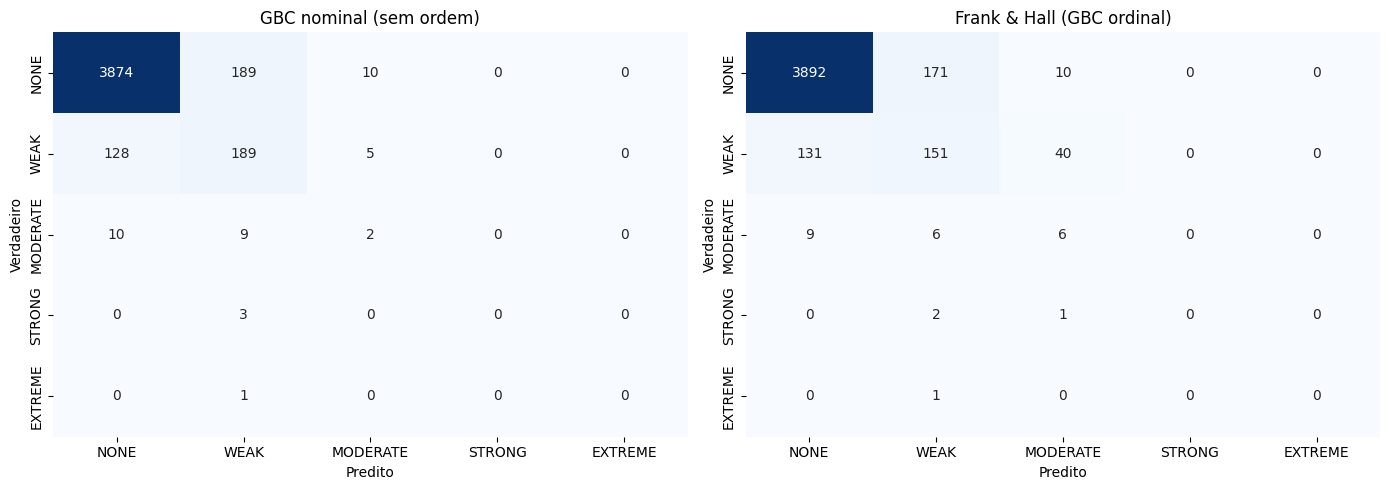


Classification report — Frank & Hall (GBC):
              precision    recall  f1-score   support

        NONE       0.97      0.96      0.96      4073
        WEAK       0.46      0.47      0.46       322
    MODERATE       0.11      0.29      0.15        21
      STRONG       0.00      0.00      0.00         3
     EXTREME       0.00      0.00      0.00         1

    accuracy                           0.92      4420
   macro avg       0.31      0.34      0.32      4420
weighted avg       0.92      0.92      0.92      4420



In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nome, y_pred) in zip(
    axes,
    [
        ("GBC nominal (sem ordem)", y_pred_nominal),
        ("Frank & Hall (GBC ordinal)", y_pred_fh_cat),
    ],
):
    cm = confusion_matrix(y_test, y_pred, labels=classes_precipitacao)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes_precipitacao,
        yticklabels=classes_precipitacao,
        ax=ax,
        cbar=False,
    )
    ax.set_xlabel("Predito")
    ax.set_ylabel("Verdadeiro")
    ax.set_title(nome)

plt.tight_layout()
plt.show()

print("\nClassification report — Frank & Hall (GBC):")
print(classification_report(
    y_test, y_pred_fh_cat, labels=classes_precipitacao, zero_division=0
))


## 2.8 Discussão

A decomposição Frank & Hall consegue aproveitar a ordem das classes mesmo num cenário tão desbalanceado. O ganho fica mais visível nas métricas sensíveis à ordinalidade (**MAE ordinal** e **QWK**) do que na accuracy bruta — exatamente o que o paper prevê e o que se observa nos resultados acima vs. a `LogReg nominal` e vs. o `Dummy`.

**Limites dos dados (e não do método):** STRONG (6 amostras no treino) e EXTREME (1) tipicamente não são preditas. Não há classificador binário capaz de aprender uma fronteira útil para `y > STRONG` com apenas 1 positivo. Essa limitação aparece explicitamente na matriz de confusão.

**Por que não fizemos merge nem SMOTE?** Optamos por (a) manter as 5 classes originais conforme o enunciado, (b) usar `class_weight='balanced'` em cada classificador binário para compensar o desbalanceamento sem alterar dados, e (c) estratificar o split para reduzir a aleatoriedade na avaliação. SMOTE não funciona com 1 amostra positiva (precisa de vizinhos da mesma classe) e tende a gerar sinal sintético pouco confiável em classes tão raras. Merge esconderia informação ordinal real (a diferença entre chuva moderada e forte importa em uma aplicação meteorológica).
